In [1]:
clean_up = True # if True, remove all gams related files from working folder before starting
%run stdPackages.ipynb

*Load specific modules used here:*

In [2]:
os.chdir(d['py'])
import mCGE, mOther

# Test of abatement module

****

*Load model:*

In [3]:
t0 = 2019
name = 'NCP_H2M0'
M = mCGE.NCP_CGE.load(os.path.join(d['data'], name))
scale = M.db._scale
ws = M.ws
tPlot = M.db('t')[0:60] # what time horizon are we looking at in plots

Initial guess:

In [4]:
from scipy import stats
t = t0
M̄ = M.db('uCO2') * adj.rc_pd(M.db('qS'), M.db('uCO2'))
μ = M.db('uKEOP')
θ = M.db('techPot')
τ = M.db('tauCO2')
δ = M.db('rDeprEOP')
γ = M.db('adjCostParEOP')
g = M.db('g_LR')
σ = M.db('techSmooth')
κ = M.db('qKmin')
R = M.db('Rrate')

In [5]:
def demand(p, M̄, θ, μ,τ, σ, t):
    return demand_t(pt.xs(t), M̄.xs(t), θ.xs(t), μ.xs(t), τ.xs(t), σ.xs(t))
def demand_t(pt, M̄t, θt, μt, τt, σt):
    return (M̄t * θt * μt * stats.norm.cdf(np.log(τt/adjMultiIndex.bc(pt*μt, τt))/σt - σt/2)).groupby('tech').sum()
def invdem_t(kt, M̄t, θt, μt, τt, σt):
    return (τt/μt) / np.exp( σt * (kt/((M̄t*θt*μt).dropna().groupby('tech').sum())).apply(stats.norm.ppf) +σt**2/2)
def backOut_it(kt, ktp, δ, g):
    return ktp*(1+g)-kt*(1-δ)
def lom_t(kt, it, δ,g):
    return (kt*(1-δ)+it)/(1+g)
def invest_t(kt, κt, λt, δ, g, γ):
    return (κt+kt)*((λt-1)/γ+δ+g)-κt*(δ+g)
def shadowVal_intra(it,kt,κt,δ,g,γ):
    return 1+γ*((it+(δ+g)*κt)/(kt+κt)-(δ+g))
def shadowVal_quad(pt, λt, δ, g, γ, Rt):
    return γ * (np.sqrt((1+g-1/γ)**2+(2/γ)*(δ+g+λt*Rt-pt-1/(2*γ)))-(1+g-1/γ))

Store values in:

In [6]:
p = pd.DataFrame(0, index = M.db('t'), columns = M.db('tech'), dtype = float)
k = pd.DataFrame(0, index = M.db('t'), columns = M.db('tech'), dtype = float)
i = pd.DataFrame(0, index = M.db('t'), columns = M.db('tech'), dtype = float)
λ = pd.DataFrame(0, index = M.db('t'), columns = M.db('tech'), dtype = float)

*First iteration:*

In [7]:
k.loc[t0] = M.db('qKEOP').xs(t0)
p.loc[t0+1] = M.db('pKEOP').xs(t0+1)
k.loc[t0+1] = demand_t(p.loc[t0+1], M̄.xs(t0+1), θ.xs(t0+1), μ.xs(t0+1), τ.xs(t0+1), σ.xs(t0+1))
i.loc[t0] = backOut_it(k.loc[t0], k.loc[t0+1], δ,g)
λ.loc[t0] = shadowVal_intra(i.loc[t0], k.loc[t0], κ.xs(t0), δ, g, γ)
λ.loc[t0+1] = shadowVal_quad(p.loc[t0+1], λ.loc[t0], δ, g, γ, R.xs(t0))

Iterate:

In [8]:
for t in p.index[1:-1]:
    i.loc[t] = invest_t(k.loc[t], κ.xs(t), λ.loc[t], δ, g, γ)
    k.loc[t+1] = lom_t(k.loc[t], i.loc[t], δ,g)
    τt = adjMultiIndex.applyMult(τ.xs(t+1), M.db('dTechSN').droplevel('t')).groupby('tech').mean()
    σt = σ.xs(t+1).groupby('tech').mean()
    p.loc[t+1] = invdem_t(k.loc[t+1], M̄.xs(t+1), θ.xs(t+1), μ.xs(t+1), τt, σt)
    λ.loc[t+1] = shadowVal_quad(p.loc[t+1], λ.loc[t], δ, g, γ, R.xs(t))

# Iterate backwards:

In [9]:
def λIte(λp, pp, ĩp, k̃p, δ, g, γ, R):
    return (1/R)*(λp*(1-δ)+pp-(γ/2)*((δ+g)**2-(ĩp/k̃p)**2))
def kIte(kp, λt, κt, δ,g,γ):
    return (kp*(1+g)-κt*(λt-1)/γ)/(1+g+(λt-1)/γ)

Guess long run price:

In [10]:
p = pd.DataFrame(0, index = M.db('t'), columns = M.db('tech'), dtype = float)
k = pd.DataFrame(0, index = M.db('t'), columns = M.db('tech'), dtype = float)
i = pd.DataFrame(0, index = M.db('t'), columns = M.db('tech'), dtype = float)
λ = pd.DataFrame(0, index = M.db('t'), columns = M.db('tech'), dtype = float)

Terminal solution:

In [11]:
T = p.index[-2]
p.loc[T] = M.db('pKEOP').xs(T)*0.99999996616782 # initial guess
k.loc[T] = demand_t(p.loc[T], M̄.xs(T), θ.xs(T), μ.xs(T), τ.xs(T), σ.xs(T))
i.loc[T] = backOut_it(k.loc[T], k.loc[T], δ, g)
λ.loc[T] = 1

Iterate back:

<Axes: xlabel='t'>

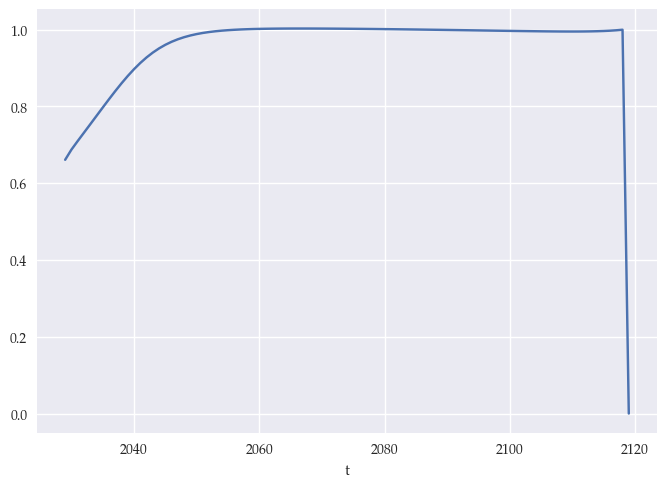

In [14]:
for t in p.index[-3::-1]:
    λ.loc[t] = λIte(λ.loc[t+1], p.loc[t+1], i.loc[t+1]+κ.xs(t+1)*(δ+g), k.loc[t+1]+κ.xs(t+1), δ,g,γ,R.xs(t))
    k.loc[t] = kIte(k.loc[t+1], λ.loc[t], κ.xs(t), δ,g,γ)
    i.loc[t] = backOut_it(k.loc[t], k.loc[t+1], δ, g)
    τt = adjMultiIndex.applyMult(τ.xs(t), M.db('dTechSN').droplevel('t')).groupby('tech').mean()
    σt = σ.xs(t).groupby('tech').mean()
    p.loc[t] = invdem_t(k.loc[t], M̄.xs(t), θ.xs(t), μ.xs(t), τt, σt)    
λ['CCS2'].dropna().plot()

# Gridded solution

In [13]:
θ = θ.xs('CCS0',level='tech')
τ = M.db('tauCO2agg')
μ = μ.xs('CCS0',level='tech')
σ = σ.xs('CCS0',level='tech').groupby('t').mean()
δ = δ.xs('CCS0')
γ = γ.xs('CCS0')
κ = κ.xs('CCS0',level='tech')

Try 2d grid:

In [15]:
kidx = pd.Index(range(25), name = 'kidx')
λidx = pd.Index(range(50), name = 'λidx')
nidx = pd.MultiIndex.from_product([kidx, λidx])
kgrid1d = pd.Series(np.linspace(1e-8,1,25), index = kidx)
λgrid1d = pd.Series(np.linspace(0.5, 2, 50), index = λidx)
kgridnd = adjMultiIndex.bc(kgrid1d, nidx)
λgridnd = adjMultiIndex.bc(λgrid1d, nidx)

In [16]:
def demand_t(pt, M̄t, θt, μt, τt, σt):
    return (M̄t * θt * μt).sum() * stats.norm.cdf(np.log(τt/(pt*μt))/σt - σt/2)
def invdem_t(kt, M̄t, θt, μt, τt, σt):
    return (τt/μt) / np.exp( σt * (kt/(M̄t*θt*μt).sum()).apply(stats.norm.ppf) +σt**2/2)

Demand functions. 

In [17]:
t = t0
τ = M.db('tauCO2agg')
pt = 0.1

Collect solution grids for each t:

In [18]:
sols = dict.fromkeys(M.db('t'))
for t in M.db('t'):
    sols[t] = {'p': invdem_t(kgridnd, M̄.xs(t), θ.xs(t), μ.xs(t), τ.xs(t), σ.xs(t))}
    sols[t]['λ'] = shadowVal_quad(sols[t]['p'], λgridnd, δ, g, γ, R.xs(t))
    sols[t]['i'] = invest_t(kgridnd, κ.xs(t), sols[t]['λ'], δ, g, γ)
    sols[t]['k'] = lom_t(kgridnd, sols[t]['i'], δ,g)

C:\Users\sxj477\AppData\Local\anaconda3\envs\GAMS46\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


Get starting values:

In [19]:
k0 = M.db('qKEOP').xs(t0).xs('CCS0')
p1 = M.db('pKEOP').xs(t0+1).xs('CCS0')
k1 = demand_t(p1, M̄.xs(t0+1), θ.xs(t0+1), μ.xs(t0+1), τ.xs(t0+1), σ.xs(t0+1))
i0 = backOut_it(k0, k1, δ,g)
λ0 = shadowVal_intra(i0,k0,κ.xs(t0),δ,g,γ)

Linear interpolation:

In [20]:
from scipy import interpolate

In [30]:
λ1 = interpolate.interpn((kgrid1d, λgrid1d), sols[t0+1]['λ'].unstack('λidx').values, [(k1, λ0)])
k2 = interpolate.interpn((kgrid1d, λgrid1d), sols[t0+1]['k'].unstack('λidx').values, [(k1, λ0)])